In [1]:
# ============================================
# SWIGGY INSTAMART ANALYTICS
# 02 - PRODUCT FUNNEL ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

np.random.seed(42)

sns.set_style("whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "instamart_cleaned.csv"
)

OUTPUT_FIGURES = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

OUTPUT_TABLES = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

instamart = pd.read_csv(
    DATA_PATH
)

print("Dataset loaded!")
print("Shape:", instamart.shape)

Dataset loaded!
Shape: (33449, 11)


In [12]:
instamart.head()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000008,CUST9935,Swiggy Instamart,NaN,16,Personal Care,195,"Horrible experience, never ordering again.",1,No,Yes
1,ORD000015,CUST4811,Swiggy Instamart,NaN,33,Fruits & Vegetables,50,"Easy to order, loved it!",5,No,No
2,ORD000017,CUST1434,Swiggy Instamart,NaN,41,Beverages,956,"Not fresh, disappointed.",2,Yes,Yes
3,ORD000018,CUST4257,Swiggy Instamart,2026-08-24 23:29:30,27,Beverages,161,Excellent experience!,5,No,No
4,ORD000019,CUST9928,Swiggy Instamart,2026-08-24 15:29:30,34,Dairy,417,"Horrible experience, never ordering again.",1,No,Yes


In [6]:
from pathlib import Path

# Notebook is inside the "notebooks" folder,
# so go one level up to the project root.
PROJECT_ROOT = Path.cwd().parent

# Original dataset
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "Ecommerce_Delivery_Analytics_New.csv"
)

# Output folders
OUTPUT_FIGURES = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

OUTPUT_TABLES = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset path:")
print(DATA_PATH)

print("\nDataset exists:", DATA_PATH.exists())

Project root:
c:\Users\dell\Desktop\Placement\Projects\Swiggy_Instamart_Analytics

Dataset path:
c:\Users\dell\Desktop\Placement\Projects\Swiggy_Instamart_Analytics\data\Ecommerce_Delivery_Analytics_New.csv

Dataset exists: True


In [13]:
instamart.head()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000008,CUST9935,Swiggy Instamart,NaN,16,Personal Care,195,"Horrible experience, never ordering again.",1,No,Yes
1,ORD000015,CUST4811,Swiggy Instamart,NaN,33,Fruits & Vegetables,50,"Easy to order, loved it!",5,No,No
2,ORD000017,CUST1434,Swiggy Instamart,NaN,41,Beverages,956,"Not fresh, disappointed.",2,Yes,Yes
3,ORD000018,CUST4257,Swiggy Instamart,2026-08-24 23:29:30,27,Beverages,161,Excellent experience!,5,No,No
4,ORD000019,CUST9928,Swiggy Instamart,2026-08-24 15:29:30,34,Dairy,417,"Horrible experience, never ordering again.",1,No,Yes


In [14]:
instamart.isnull().sum()

Order ID                       0
Customer ID                    0
Platform                       0
Order Date & Time          20129
Delivery Time (Minutes)        0
Product Category               0
Order Value (INR)              0
Customer Feedback              0
Service Rating                 0
Delivery Delay                 0
Refund Requested               0
dtype: int64

In [15]:
customer_history = (
    instamart
    .groupby("Customer ID")
    .agg(
        Historical_Avg_Rating=(
            "Service Rating",
            "mean"
        ),

        Historical_Delay_Rate=(
            "Delivery Delay",
            lambda x: (x == "Yes").mean()
        ),

        Historical_Refund_Rate=(
            "Refund Requested",
            lambda x: (x == "Yes").mean()
        ),

        Historical_Order_Frequency=(
            "Order ID",
            "nunique"
        )
    )
    .reset_index()
)

customer_history.head()

,Customer ID,Historical_Avg_Rating,Historical_Delay_Rate,Historical_Refund_Rate,Historical_Order_Frequency
0,CUST1000,3.500000,0.000000,0.500000,2
1,CUST1001,3.111111,0.111111,0.555556,9
2,CUST1002,3.000000,0.000000,0.333333,3
3,CUST1003,2.666667,0.333333,0.666667,3
4,CUST1004,5.000000,0.000000,0.000000,1


In [16]:
instamart = instamart.merge(
    customer_history,
    on="Customer ID",
    how="left"
)

print(instamart.shape)

(33449, 15)


In [17]:
BASE_PROBABILITIES = {
    "Category Browse": 0.80,
    "Add to Cart": 0.55,
    "Checkout Initiated": 0.75
}

BASE_PROBABILITIES

{'Category Browse': 0.8, 'Add to Cart': 0.55, 'Checkout Initiated': 0.75}

In [18]:
def generate_funnel(row):

    # -----------------------------
    # Baseline probabilities
    # -----------------------------

    p_browse = BASE_PROBABILITIES["Category Browse"]
    p_cart = BASE_PROBABILITIES["Add to Cart"]
    p_checkout = BASE_PROBABILITIES["Checkout Initiated"]


    # -----------------------------
    # Delivery delay effect
    # -----------------------------

    if row["Delivery Delay"] == "Yes":

        p_browse -= 0.05
        p_cart -= 0.10
        p_checkout -= 0.10


    # -----------------------------
    # Low rating effect
    # -----------------------------

    if row["Historical_Avg_Rating"] < 3:

        p_browse -= 0.08
        p_cart -= 0.10
        p_checkout -= 0.10


    # -----------------------------
    # High historical delay effect
    # -----------------------------

    if row["Historical_Delay_Rate"] > 0.30:

        p_cart -= 0.08
        p_checkout -= 0.08


    # -----------------------------
    # High refund rate effect
    # -----------------------------

    if row["Historical_Refund_Rate"] > 0.50:

        p_cart -= 0.05
        p_checkout -= 0.05


    # -----------------------------
    # Keep probabilities valid
    # -----------------------------

    p_browse = np.clip(p_browse, 0.10, 0.95)
    p_cart = np.clip(p_cart, 0.10, 0.95)
    p_checkout = np.clip(p_checkout, 0.10, 0.95)


    # -----------------------------
    # Sequential funnel
    # -----------------------------

    app_open = True

    category_browse = (
        np.random.random() < p_browse
    )

    add_to_cart = (
        category_browse
        and np.random.random() < p_cart
    )

    checkout = (
        add_to_cart
        and np.random.random() < p_checkout
    )

    # Every row in the source dataset
    # represents a completed order.
    order_complete = True


    return pd.Series({
        "App Open": int(app_open),
        "Category Browse": int(category_browse),
        "Add to Cart": int(add_to_cart),
        "Checkout Initiated": int(checkout),
        "Order Complete": int(order_complete)
    })

In [19]:
funnel_events = instamart.apply(
    generate_funnel,
    axis=1
)

instamart_funnel = pd.concat(
    [
        instamart.reset_index(drop=True),
        funnel_events.reset_index(drop=True)
    ],
    axis=1
)

print(
    "Funnel dataset shape:",
    instamart_funnel.shape
)

Funnel dataset shape: (33449, 20)


In [20]:
instamart_funnel[
    [
        "Order ID",
        "Customer ID",
        "Delivery Delay",
        "Service Rating",
        "Historical_Avg_Rating",
        "App Open",
        "Category Browse",
        "Add to Cart",
        "Checkout Initiated",
        "Order Complete"
    ]
].head(10)

,Order ID,Customer ID,Delivery Delay,Service Rating,Historical_Avg_Rating,App Open,Category Browse,Add to Cart,Checkout Initiated,Order Complete
0,ORD000008,CUST9935,No,1,1.000000,1,1,0,0,1
1,ORD000015,CUST4811,No,5,3.000000,1,1,0,0,1
2,ORD000017,CUST1434,Yes,2,2.600000,1,1,1,1,1
3,ORD000018,CUST4257,No,5,3.200000,1,0,0,0,1
4,ORD000019,CUST9928,No,1,1.500000,1,1,0,0,1
5,ORD000020,CUST7873,No,5,3.666667,1,1,0,0,1
6,ORD000023,CUST5557,No,4,2.500000,1,0,0,0,1
7,ORD000024,CUST1106,No,3,2.500000,1,1,1,1,1
8,ORD000031,CUST6514,No,5,2.666667,1,1,0,0,1
9,ORD000033,CUST2519,No,5,3.500000,1,1,1,1,1


In [21]:
print(instamart_funnel[
    [
        "App Open",
        "Category Browse",
        "Add to Cart",
        "Checkout Initiated",
        "Order Complete"
    ]
].sum())

App Open              33449
Category Browse       25597
Add to Cart           12204
Checkout Initiated     8524
Order Complete        33449
dtype: int64


In [22]:
funnel_steps = [
    "App Open",
    "Category Browse",
    "Add to Cart",
    "Checkout Initiated",
    "Order Complete"
]

funnel_counts = pd.DataFrame({
    "Funnel Step": funnel_steps,
    "Users": [
        instamart_funnel[step].sum()
        for step in funnel_steps
    ]
})

# Conversion relative to App Open
funnel_counts["Overall_Conversion_%"] = (
    funnel_counts["Users"]
    / funnel_counts["Users"].iloc[0]
    * 100
)

# Conversion from previous step
funnel_counts["Step_Conversion_%"] = (
    funnel_counts["Users"]
    .div(funnel_counts["Users"].shift(1))
    * 100
)

# Drop-off from previous step
funnel_counts["Step_Dropoff_%"] = (
    100 - funnel_counts["Step_Conversion_%"]
)

funnel_counts

,Funnel Step,Users,Overall_Conversion_%,Step_Conversion_%,Step_Dropoff_%
0,App Open,33449,100.000000,NaN,NaN
1,Category Browse,25597,76.525457,76.525457,23.474543
2,Add to Cart,12204,36.485396,47.677462,52.322538
3,Checkout Initiated,8524,25.483572,69.845952,30.154048
4,Order Complete,33449,100.000000,392.409667,-292.409667


In [23]:
# Exclude App Open because it has no previous step
friction_points = funnel_counts.iloc[1:4].copy()

biggest_friction = friction_points.loc[
    friction_points["Step_Dropoff_%"].idxmax()
]

print(
    "Biggest modeled friction point:",
    biggest_friction["Funnel Step"]
)

print(
    f"Drop-off: "
    f"{biggest_friction['Step_Dropoff_%']:.2f}%"
)

Biggest modeled friction point: Add to Cart
Drop-off: 52.32%


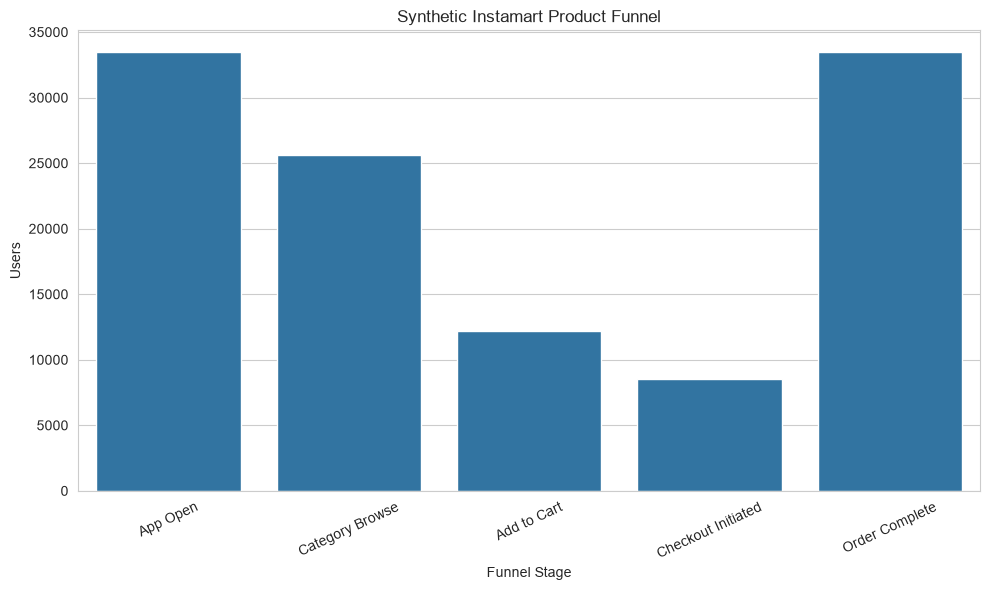

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=funnel_counts,
    x="Funnel Step",
    y="Users"
)

plt.title("Synthetic Instamart Product Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Users")

plt.xticks(rotation=25)
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "synthetic_funnel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
funnel_counts.to_csv(
    OUTPUT_TABLES / "funnel_analysis.csv",
    index=False
)

print("Funnel analysis saved.")

Funnel analysis saved.


In [26]:
# ==========================================
# SYNTHETIC SESSION GENERATION
# ==========================================

N_SESSIONS = 100_000

# Sample customers from the real Instamart customer base
session_customers = np.random.choice(
    customer_history["Customer ID"],
    size=N_SESSIONS,
    replace=True
)

synthetic_sessions = pd.DataFrame({
    "Session_ID": [
        f"SESSION_{i:06d}"
        for i in range(1, N_SESSIONS + 1)
    ],
    "Customer ID": session_customers
})

# Attach observed customer experience
synthetic_sessions = synthetic_sessions.merge(
    customer_history,
    on="Customer ID",
    how="left"
)

print("Synthetic sessions:", len(synthetic_sessions))

Synthetic sessions: 100000


In [27]:
# ==========================================
# FUNNEL SIMULATION
# ==========================================

# Every synthetic session starts with an app open
synthetic_sessions["App Open"] = 1


# ------------------------------------------
# 1. Category Browse
# ------------------------------------------

p_browse = np.full(
    N_SESSIONS,
    0.82
)

# Poor historical rating reduces engagement
p_browse -= np.where(
    synthetic_sessions["Historical_Avg_Rating"] < 3,
    0.08,
    0
)

# High historical refund rate
p_browse -= np.where(
    synthetic_sessions["Historical_Refund_Rate"] > 0.50,
    0.05,
    0
)

p_browse = np.clip(
    p_browse,
    0.10,
    0.95
)

synthetic_sessions["Category Browse"] = (
    np.random.random(N_SESSIONS)
    < p_browse
).astype(int)


# ------------------------------------------
# 2. Add to Cart
# ------------------------------------------

p_cart = np.full(
    N_SESSIONS,
    0.55
)

p_cart -= np.where(
    synthetic_sessions["Historical_Avg_Rating"] < 3,
    0.10,
    0
)

p_cart -= np.where(
    synthetic_sessions["Historical_Delay_Rate"] > 0.30,
    0.08,
    0
)

p_cart -= np.where(
    synthetic_sessions["Historical_Refund_Rate"] > 0.50,
    0.05,
    0
)

p_cart = np.clip(
    p_cart,
    0.10,
    0.95
)

synthetic_sessions["Add to Cart"] = (
    (
        synthetic_sessions["Category Browse"] == 1
    )
    &
    (
        np.random.random(N_SESSIONS)
        < p_cart
    )
).astype(int)


# ------------------------------------------
# 3. Checkout Initiated
# ------------------------------------------

p_checkout = np.full(
    N_SESSIONS,
    0.75
)

p_checkout -= np.where(
    synthetic_sessions["Historical_Avg_Rating"] < 3,
    0.10,
    0
)

p_checkout -= np.where(
    synthetic_sessions["Historical_Delay_Rate"] > 0.30,
    0.08,
    0
)

p_checkout -= np.where(
    synthetic_sessions["Historical_Refund_Rate"] > 0.50,
    0.05,
    0
)

p_checkout = np.clip(
    p_checkout,
    0.10,
    0.95
)

synthetic_sessions["Checkout Initiated"] = (
    (
        synthetic_sessions["Add to Cart"] == 1
    )
    &
    (
        np.random.random(N_SESSIONS)
        < p_checkout
    )
).astype(int)


# ------------------------------------------
# 4. Order Complete
# ------------------------------------------

p_complete = np.full(
    N_SESSIONS,
    0.90
)

# Checkout-stage friction
p_complete -= np.where(
    synthetic_sessions["Historical_Avg_Rating"] < 3,
    0.05,
    0
)

p_complete = np.clip(
    p_complete,
    0.10,
    0.95
)

synthetic_sessions["Order Complete"] = (
    (
        synthetic_sessions["Checkout Initiated"] == 1
    )
    &
    (
        np.random.random(N_SESSIONS)
        < p_complete
    )
).astype(int)

In [28]:
funnel_counts

,Funnel Step,Users,Overall_Conversion_%,Step_Conversion_%,Step_Dropoff_%
0,App Open,33449,100.000000,NaN,NaN
1,Category Browse,25597,76.525457,76.525457,23.474543
2,Add to Cart,12204,36.485396,47.677462,52.322538
3,Checkout Initiated,8524,25.483572,69.845952,30.154048
4,Order Complete,33449,100.000000,392.409667,-292.409667


In [29]:
print("Synthetic sessions:", len(synthetic_sessions))

print(
    synthetic_sessions[
        [
            "App Open",
            "Category Browse",
            "Add to Cart",
            "Checkout Initiated",
            "Order Complete"
        ]
    ].sum()
)

Synthetic sessions: 100000
App Open              100000
Category Browse        77640
Add to Cart            37974
Checkout Initiated     26724
Order Complete         23710
dtype: int64


In [30]:
# ==========================================
# CORRECT SYNTHETIC FUNNEL SUMMARY
# ==========================================

funnel_steps = [
    "App Open",
    "Category Browse",
    "Add to Cart",
    "Checkout Initiated",
    "Order Complete"
]

funnel_counts = pd.DataFrame({
    "Funnel Step": funnel_steps,
    "Users": [
        synthetic_sessions[step].sum()
        for step in funnel_steps
    ]
})

# Overall conversion from App Open
funnel_counts["Overall_Conversion_%"] = (
    funnel_counts["Users"]
    / funnel_counts["Users"].iloc[0]
    * 100
)

# Conversion from previous stage
funnel_counts["Step_Conversion_%"] = (
    funnel_counts["Users"]
    .div(funnel_counts["Users"].shift(1))
    * 100
)

# Drop-off from previous stage
funnel_counts["Step_Dropoff_%"] = (
    100 - funnel_counts["Step_Conversion_%"]
)

funnel_counts

,Funnel Step,Users,Overall_Conversion_%,Step_Conversion_%,Step_Dropoff_%
0,App Open,100000,100.000,NaN,NaN
1,Category Browse,77640,77.640,77.640000,22.360000
2,Add to Cart,37974,37.974,48.910355,51.089645
3,Checkout Initiated,26724,26.724,70.374467,29.625533
4,Order Complete,23710,23.710,88.721748,11.278252


In [31]:
def assign_experience_segment(row):

    if (
        row["Historical_Avg_Rating"] < 3
        or row["Historical_Delay_Rate"] > 0.30
        or row["Historical_Refund_Rate"] > 0.50
    ):
        return "High Risk Experience"

    elif (
        row["Historical_Avg_Rating"] < 4
        or row["Historical_Delay_Rate"] > 0.15
        or row["Historical_Refund_Rate"] > 0.25
    ):
        return "Medium Risk Experience"

    else:
        return "Healthy Experience"


synthetic_sessions["Experience_Segment"] = (
    synthetic_sessions
    .apply(assign_experience_segment, axis=1)
)

synthetic_sessions["Experience_Segment"].value_counts()

Experience_Segment
High Risk Experience      50443
Medium Risk Experience    34910
Healthy Experience        14647
Name: count, dtype: int64

In [32]:
segment_funnel = (
    synthetic_sessions
    .groupby("Experience_Segment")[
        [
            "App Open",
            "Category Browse",
            "Add to Cart",
            "Checkout Initiated",
            "Order Complete"
        ]
    ]
    .sum()
)

segment_funnel

,App Open,Category Browse,Add to Cart,Checkout Initiated,Order Complete
Experience_Segment,,,,,
Healthy Experience,14647,12052,6671,5014,4513
High Risk Experience,50443,37043,15670,9906,8648
Medium Risk Experience,34910,28545,15633,11804,10549


In [33]:
segment_conversion = segment_funnel.copy()

for step in [
    "Category Browse",
    "Add to Cart",
    "Checkout Initiated",
    "Order Complete"
]:
    
    previous_step = {
        "Category Browse": "App Open",
        "Add to Cart": "Category Browse",
        "Checkout Initiated": "Add to Cart",
        "Order Complete": "Checkout Initiated"
    }[step]
    
    segment_conversion[
        f"{previous_step}_to_{step}_%"
    ] = (
        segment_funnel[step]
        / segment_funnel[previous_step]
        * 100
    )

segment_conversion

,App Open,Category Browse,Add to Cart,Checkout Initiated,Order Complete,App Open_to_Category Browse_%,Category Browse_to_Add to Cart_%,Add to Cart_to_Checkout Initiated_%,Checkout Initiated_to_Order Complete_%
Experience_Segment,,,,,,,,,
Healthy Experience,14647,12052,6671,5014,4513,82.283061,55.351809,75.161145,90.007978
High Risk Experience,50443,37043,15670,9906,8648,73.435363,42.302189,63.216337,87.300626
Medium Risk Experience,34910,28545,15633,11804,10549,81.767402,54.766159,75.506940,89.368011


In [34]:
segment_funnel.to_csv(
    OUTPUT_TABLES / "segment_funnel_counts.csv"
)

segment_conversion.to_csv(
    OUTPUT_TABLES / "segment_funnel_conversion.csv"
)

print("Segment funnel analysis saved.")

Segment funnel analysis saved.


In [35]:
# ==========================================
# A/B TEST SETUP
# ==========================================

experiment = synthetic_sessions.copy()

np.random.seed(42)

experiment["Experiment_Group"] = np.random.choice(
    ["Control", "Treatment"],
    size=len(experiment),
    p=[0.50, 0.50]
)

print(
    experiment["Experiment_Group"].value_counts()
)

Experiment_Group
Treatment    50066
Control      49934
Name: count, dtype: int64


In [36]:
BASE_CART_PROBABILITY = 0.55

RELATIVE_LIFT = 0.05

TREATMENT_CART_PROBABILITY = (
    BASE_CART_PROBABILITY
    * (1 + RELATIVE_LIFT)
)

print("Control probability:",
      BASE_CART_PROBABILITY)

print("Treatment probability:",
      TREATMENT_CART_PROBABILITY)

Control probability: 0.55
Treatment probability: 0.5775000000000001


In [37]:
experiment["Add_to_Cart_AB"] = 0

browse_mask = (
    experiment["Category Browse"] == 1
)

control_mask = (
    browse_mask
    & (experiment["Experiment_Group"] == "Control")
)

treatment_mask = (
    browse_mask
    & (experiment["Experiment_Group"] == "Treatment")
)

# Control
experiment.loc[
    control_mask,
    "Add_to_Cart_AB"
] = (
    np.random.random(control_mask.sum())
    < BASE_CART_PROBABILITY
).astype(int)

# Treatment
experiment.loc[
    treatment_mask,
    "Add_to_Cart_AB"
] = (
    np.random.random(treatment_mask.sum())
    < TREATMENT_CART_PROBABILITY
).astype(int)

In [39]:
ab_summary = (
    experiment[
        experiment["Category Browse"] == 1
    ]
    .groupby("Experiment_Group")
    ["Add_to_Cart_AB"]
    .agg(
        Conversions="sum",
        Sample_Size="count"
    )
    .reset_index()
)

ab_summary["Conversion_Rate"] = (
    ab_summary["Conversions"]
    / ab_summary["Sample_Size"]
)

ab_summary


,Experiment_Group,Conversions,Sample_Size,Conversion_Rate
0,Control,21263,38644,0.550228
1,Treatment,22405,38996,0.574546


In [40]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Extract results
control = ab_summary[
    ab_summary["Experiment_Group"] == "Control"
].iloc[0]

treatment = ab_summary[
    ab_summary["Experiment_Group"] == "Treatment"
].iloc[0]

# Number of conversions
successes = np.array([
    control["Conversions"],
    treatment["Conversions"]
])

# Number of observations
sample_sizes = np.array([
    control["Sample_Size"],
    treatment["Sample_Size"]
])

# Two-sided two-proportion Z-test
z_stat, p_value = proportions_ztest(
    successes,
    sample_sizes
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -6.829460516087536
P-value: 8.52345509058988e-12


In [41]:
alpha = 0.05

if p_value < alpha:
    print("Statistically significant: Reject H0")
else:
    print("Not statistically significant: Fail to reject H0")

Statistically significant: Reject H0


In [42]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    treatment["Conversions"],
    treatment["Sample_Size"],
    control["Conversions"],
    control["Sample_Size"],
    method="wald"
)

treatment_rate = (
    treatment["Conversions"]
    / treatment["Sample_Size"]
)

control_rate = (
    control["Conversions"]
    / control["Sample_Size"]
)

observed_difference = (
    treatment_rate - control_rate
)

print(
    f"Treatment conversion: {treatment_rate:.4%}"
)

print(
    f"Control conversion: {control_rate:.4%}"
)

print(
    f"Absolute lift: {observed_difference:.4%}"
)

print(
    f"95% CI: [{ci_low:.4%}, {ci_high:.4%}]"
)

Treatment conversion: 57.4546%
Control conversion: 55.0228%
Absolute lift: 2.4318%
95% CI: [1.7341%, 3.1296%]


In [43]:
relative_lift = (
    treatment_rate - control_rate
) / control_rate

print(
    f"Relative lift: {relative_lift:.2%}"
)

Relative lift: 4.42%


In [44]:
eligible_sessions = 100_000

control_expected_orders = (
    eligible_sessions * control_rate
)

treatment_expected_orders = (
    eligible_sessions * treatment_rate
)

incremental_orders = (
    treatment_expected_orders
    - control_expected_orders
)

avg_order_value = (
    instamart["Order Value (INR)"].mean()
)

incremental_revenue = (
    incremental_orders
    * avg_order_value
)

print(
    f"Expected control orders: "
    f"{control_expected_orders:,.0f}"
)

print(
    f"Expected treatment orders: "
    f"{treatment_expected_orders:,.0f}"
)

print(
    f"Incremental orders: "
    f"{incremental_orders:,.0f}"
)

print(
    f"Average order value: "
    f"₹{avg_order_value:,.2f}"
)

print(
    f"Estimated incremental revenue: "
    f"₹{incremental_revenue:,.2f}"
)

Expected control orders: 55,023
Expected treatment orders: 57,455
Incremental orders: 2,432
Average order value: ₹592.90
Estimated incremental revenue: ₹1,441,842.43


In [46]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline_rate = 0.55
expected_rate = 0.5775

effect_size = proportion_effectsize(
    baseline_rate,
    expected_rate
)

power_analysis = NormalIndPower()

required_sample = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative="two-sided"
)

print(
    f"Required sample size per group: "
    f"{np.ceil(required_sample):,.0f}"
)

print(
    f"Total required sample size: "
    f"{np.ceil(required_sample * 2):,.0f}"
)

Required sample size per group: 5,104
Total required sample size: 10,208


In [47]:
# ==========================================
# FINAL POWER BI EXPORTS
# ==========================================

POWERBI_DIR = PROJECT_ROOT / "outputs" / "powerbi"

POWERBI_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Power BI folder:", POWERBI_DIR)

Power BI folder: c:\Users\dell\Desktop\Placement\Projects\Swiggy_Instamart_Analytics\outputs\powerbi


In [48]:
# Funnel
funnel_counts.to_csv(
    POWERBI_DIR / "funnel_analysis.csv",
    index=False
)

# Segment funnel
segment_conversion.to_csv(
    POWERBI_DIR / "segment_funnel_conversion.csv"
)

# A/B test
ab_summary.to_csv(
    POWERBI_DIR / "ab_test_results.csv",
    index=False
)

# Customer history
customer_history.to_csv(
    POWERBI_DIR / "customer_history.csv",
    index=False
)

# Main Instamart dataset
instamart.to_csv(
    POWERBI_DIR / "instamart_orders.csv",
    index=False
)

print("All Power BI files exported successfully.")

All Power BI files exported successfully.
